# Bioformats Benchmark

Benchmark suite comparing BAM, VCF, and FASTQ reading performance across pysam, oxbow, biobear, and polars-bio.

In [1]:
import json
import os
import subprocess
import sys
import time
from pathlib import Path

import polars as pl

# Configuration
NUM_RUNS = 2
THREAD_COUNTS = [1, 2, 4, 8]
ENABLE_PYSAM = True  # Toggle pysam benchmarks on/off
PROJECT_ROOT = Path(".").resolve()
PYTHON_MAIN = str(PROJECT_ROOT / ".venv" / "bin" / "python")
PYTHON_BASELINE = str(PROJECT_ROOT / ".venv-baseline" / "bin" / "python")
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

# Data paths (FASTQ uses bgzip for parallel decompression)
BAM_PATH = "/Users/mwiewior/research/data/WES/NA12878.proper.wes.md.chr1.bam"
VCF_PATH = "/Users/mwiewior/research/data/VCF/homo_sapiens-chr1.vcf.gz"
FASTQ_PATH = "/Users/mwiewior/research/data/FASTQ/ERR194158.fastq.bgz"

DATA_PATHS = {"bam": BAM_PATH, "vcf": VCF_PATH, "fastq": FASTQ_PATH}

# Results store: keyed by (format, variant, library, threads) → list of runs
# Rerunning a benchmark cell OVERWRITES only its keys, keeping the rest
all_results = {}

def store_result(r):
    """Store a benchmark result, keeping only the last NUM_RUNS per key."""
    key = (r["format"], r["variant"], r["library"], r["threads"])
    all_results.setdefault(key, []).append(r)
    all_results[key] = all_results[key][-NUM_RUNS:]

# Auto-load previous results from JSON (so you can rerun a single cell
# without losing results from other cells)
_saved = RESULTS_DIR / "all_results.json"
if _saved.exists() and _saved.stat().st_size > 10:
    _df = pl.read_json(_saved)
    for _r in _df.to_dicts():
        store_result(_r)
    print(f"Loaded {len(_df)} saved results ({len(all_results)} groups)")
else:
    print("No saved results found — starting fresh")

print(f"Project root: {PROJECT_ROOT}")
print(f"Main Python:     {PYTHON_MAIN}")
print(f"Baseline Python: {PYTHON_BASELINE}")
print(f"NUM_RUNS: {NUM_RUNS}")
print(f"ENABLE_PYSAM: {ENABLE_PYSAM}")

Loaded 98 saved results (49 groups)
Project root: /Users/mwiewior/research/git/bioformats-benchmark
Main Python:     /Users/mwiewior/research/git/bioformats-benchmark/.venv/bin/python
Baseline Python: /Users/mwiewior/research/git/bioformats-benchmark/.venv-baseline/bin/python
NUM_RUNS: 2
ENABLE_PYSAM: True


In [2]:
# Detect library versions

def get_version(python_path, package):
    """Get package version from a venv using importlib.metadata."""
    try:
        result = subprocess.run(
            [python_path, "-c", f"import importlib.metadata; print(importlib.metadata.version('{package}'))"],
            capture_output=True, text=True, timeout=10
        )
        return result.stdout.strip() if result.returncode == 0 else "unknown"
    except Exception:
        return "unknown"

VERSIONS = {
    "pysam": get_version(PYTHON_MAIN, "pysam"),
    "oxbow": get_version(PYTHON_MAIN, "oxbow"),
    "biobear": get_version(PYTHON_MAIN, "biobear"),
    "polars_bio_baseline": get_version(PYTHON_BASELINE, "polars-bio"),
    "polars_bio_prerelease": get_version(PYTHON_MAIN, "polars-bio"),
}
VERSIONS["pysam_chunked"] = get_version(PYTHON_MAIN, "pysam")  # same package

# Build display labels
LABELS = {
    "pysam": f"pysam-{VERSIONS['pysam']}",
    "pysam_chunked": f"pysam-{VERSIONS['pysam']}-chunked",
    "oxbow": f"oxbow-{VERSIONS['oxbow']}",
    "oxbow_stream": f"oxbow-{VERSIONS['oxbow']}-stream",
    "biobear": f"biobear-{VERSIONS['biobear']}",
    "polars_bio_baseline": f"polars-bio-{VERSIONS['polars_bio_baseline']}",
    "polars_bio_prerelease": f"polars-bio-0.23.0",
}

print("Library versions:")
for k, v in LABELS.items():
    print(f"  {k}: {v}")

Library versions:
  pysam: pysam-0.23.3
  pysam_chunked: pysam-0.23.3-chunked
  oxbow: oxbow-0.5.1
  oxbow_stream: oxbow-0.5.1-stream
  biobear: biobear-0.23.7
  polars_bio_baseline: polars-bio-0.22.0
  polars_bio_prerelease: polars-bio-0.23.0


In [3]:
# Benchmark subprocess runner

import threading

try:
    import psutil
    HAS_PSUTIL = True
except ImportError:
    HAS_PSUTIL = False

TIMEOUT_SECONDS = 3600  # 60 min per run


def _poll_memory(proc, result_holder, stop_event):
    """Poll peak RSS in a background thread while subprocess runs."""
    if not HAS_PSUTIL:
        return
    try:
        ps_proc = psutil.Process(proc.pid)
    except psutil.NoSuchProcess:
        return
    peak_mb = 0.0
    while not stop_event.is_set():
        try:
            mem_info = ps_proc.memory_info()
            current_mb = mem_info.rss / (1024 * 1024)
            for child in ps_proc.children(recursive=True):
                try:
                    current_mb += child.memory_info().rss / (1024 * 1024)
                except (psutil.NoSuchProcess, psutil.AccessDenied):
                    pass
            peak_mb = max(peak_mb, current_mb)
        except (psutil.NoSuchProcess, psutil.AccessDenied):
            break
        stop_event.wait(0.5)
    result_holder["peak_mb"] = peak_mb


def run_benchmark_subprocess(script_module, python_path, env_overrides=None, num_runs=NUM_RUNS):
    """Run a benchmark script as a subprocess, polling memory in a thread.
    
    Returns list of result dicts (one per run).
    """
    env = {**os.environ}
    if env_overrides:
        env.update(env_overrides)
    
    cmd = [python_path, "-m", script_module]
    runs = []
    
    for run_id in range(num_runs):
        print(f"  Starting run {run_id+1}/{num_runs} ... ", end="", flush=True)
        start = time.perf_counter()
        proc = subprocess.Popen(
            cmd, cwd=str(PROJECT_ROOT), env=env,
            stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True,
        )
        
        # Poll memory in background thread
        mem_result = {"peak_mb": 0.0}
        stop_event = threading.Event()
        mem_thread = threading.Thread(target=_poll_memory, args=(proc, mem_result, stop_event))
        mem_thread.start()
        
        # communicate() drains pipes and waits — no deadlock
        try:
            stdout, stderr = proc.communicate(timeout=TIMEOUT_SECONDS)
        except subprocess.TimeoutExpired:
            proc.kill()
            stdout, stderr = proc.communicate()
            stop_event.set()
            mem_thread.join()
            print(f"TIMEOUT after {TIMEOUT_SECONDS}s")
            continue
        
        stop_event.set()
        mem_thread.join()
        
        wall_time = time.perf_counter() - start
        external_peak_mb = mem_result["peak_mb"]
        
        if proc.returncode != 0:
            print(f"FAILED (rc={proc.returncode}, {wall_time:.1f}s)")
            if stderr:
                print(f"  STDERR: {stderr[:500]}")
            continue
        
        # Check for SKIP
        if "SKIP:" in stdout:
            print(f"SKIPPED")
            return []
        
        # Parse BENCHMARK_RESULT
        result = None
        for line in stdout.split("\n"):
            if line.startswith("BENCHMARK_RESULT:"):
                try:
                    result = json.loads(line[len("BENCHMARK_RESULT:"):])
                except json.JSONDecodeError as e:
                    print(f"JSON ERROR: {e}")
                break
        
        if result is None:
            print(f"NO RESULT ({wall_time:.1f}s)")
            if stdout:
                print(f"  STDOUT: {stdout[:500]}")
            if stderr:
                print(f"  STDERR: {stderr[:500]}")
            continue
        
        result["external_peak_mb"] = round(external_peak_mb, 1)
        result["wall_time_seconds"] = round(wall_time, 3)
        result["run_id"] = run_id
        runs.append(result)
        
        print(f"{result['time_seconds']:.3f}s, "
              f"RSS={result['peak_rss_mb']:.0f}MB, ext={external_peak_mb:.0f}MB, "
              f"rows={result['row_count']}")
    
    return runs

print("Runner ready.")

Runner ready.


In [3]:
# Benchmark matrix: (format, variant, library_key, module)
# library_key maps to LABELS for display

NON_PB_BENCHMARKS = [
    # FASTQ
    ("fastq", "all_columns", "pysam", "benchmarks.bench_fastq_pysam"),
    ("fastq", "all_columns", "pysam_chunked", "benchmarks.bench_fastq_pysam_chunked"),
    ("fastq", "all_columns", "oxbow", "benchmarks.bench_fastq_oxbow"),
    ("fastq", "all_columns", "oxbow_stream", "benchmarks.bench_fastq_oxbow_stream"),
    ("fastq", "all_columns", "biobear", "benchmarks.bench_fastq_biobear"),
    # BAM without tags
    ("bam", "without_tags", "pysam", "benchmarks.bench_bam_pysam"),
    ("bam", "without_tags", "pysam_chunked", "benchmarks.bench_bam_pysam_chunked"),
    ("bam", "without_tags", "oxbow", "benchmarks.bench_bam_oxbow"),
    ("bam", "without_tags", "oxbow_stream", "benchmarks.bench_bam_oxbow_stream"),
    ("bam", "without_tags", "biobear", "benchmarks.bench_bam_biobear"),
    # BAM with tags
    ("bam", "with_tags", "pysam", "benchmarks.bench_bam_pysam"),
    ("bam", "with_tags", "pysam_chunked", "benchmarks.bench_bam_pysam_chunked"),
    ("bam", "with_tags", "oxbow", "benchmarks.bench_bam_oxbow"),
    ("bam", "with_tags", "oxbow_stream", "benchmarks.bench_bam_oxbow_stream"),
    ("bam", "with_tags", "biobear", "benchmarks.bench_bam_biobear"),
    # VCF without info
    ("vcf", "without_info", "pysam", "benchmarks.bench_vcf_pysam"),
    ("vcf", "without_info", "pysam_chunked", "benchmarks.bench_vcf_pysam_chunked"),
    ("vcf", "without_info", "oxbow", "benchmarks.bench_vcf_oxbow"),
    ("vcf", "without_info", "oxbow_stream", "benchmarks.bench_vcf_oxbow_stream"),
    ("vcf", "without_info", "biobear", "benchmarks.bench_vcf_biobear"),
    # VCF with info
    ("vcf", "with_info", "pysam", "benchmarks.bench_vcf_pysam"),
    ("vcf", "with_info", "pysam_chunked", "benchmarks.bench_vcf_pysam_chunked"),
    ("vcf", "with_info", "oxbow", "benchmarks.bench_vcf_oxbow"),
    ("vcf", "with_info", "oxbow_stream", "benchmarks.bench_vcf_oxbow_stream"),
    # biobear VCF with_info is SKIPPED (fails)
]

PB_FORMATS = [
    # (format, variant, module)
    ("fastq", "all_columns", "benchmarks.bench_fastq_polars_bio"),
    ("bam", "without_tags", "benchmarks.bench_bam_polars_bio"),
    ("bam", "with_tags", "benchmarks.bench_bam_polars_bio"),
    ("vcf", "without_info", "benchmarks.bench_vcf_polars_bio"),
    ("vcf", "with_info", "benchmarks.bench_vcf_polars_bio"),
]

print(f"Non-PB benchmarks: {len(NON_PB_BENCHMARKS)}")
print(f"PB format tests:   {len(PB_FORMATS)} x ({len(THREAD_COUNTS)} threads + 1 baseline)")

Non-PB benchmarks: 24
PB format tests:   5 x (4 threads + 1 baseline)


In [10]:
# Run non-polars-bio benchmarks (pysam, oxbow, biobear)

for fmt, variant, lib_key, module in NON_PB_BENCHMARKS:
    if lib_key == "pysam" and not ENABLE_PYSAM:
        continue

    data_path_key = f"{fmt.upper()}_PATH"
    env = {"BENCH_VARIANT": variant, data_path_key: DATA_PATHS[fmt]}
    
    label = LABELS[lib_key]
    print(f"\n--- {label} | {fmt} | {variant} ---")
    
    runs = run_benchmark_subprocess(module, PYTHON_MAIN, env_overrides=env)
    
    for r in runs:
        r["format"] = fmt
        r["variant"] = variant
        r["library"] = lib_key
        r["label"] = label
        r["threads"] = 1
        r["version"] = VERSIONS.get(lib_key, "unknown")
        store_result(r)

print(f"\nStored {sum(len(v) for v in all_results.values())} results in {len(all_results)} groups.")


--- pysam-0.23.3 | fastq | all_columns ---
  Starting run 1/2 ... 12.447s, RSS=8452MB, ext=8445MB, rows=10818180
  Starting run 2/2 ... 12.150s, RSS=8448MB, ext=8441MB, rows=10818180

--- oxbow-0.5.1 | fastq | all_columns ---
  Starting run 1/2 ... 8.111s, RSS=4649MB, ext=2076MB, rows=10818180
  Starting run 2/2 ... 8.044s, RSS=4676MB, ext=2421MB, rows=10818180

--- oxbow-0.5.1-stream | fastq | all_columns ---
  Starting run 1/2 ... 8.004s, RSS=238MB, ext=237MB, rows=10818180
  Starting run 2/2 ... 8.013s, RSS=243MB, ext=242MB, rows=10818180

--- biobear-0.23.7 | fastq | all_columns ---
  Starting run 1/2 ... 12.045s, RSS=4507MB, ext=3268MB, rows=10818180
  Starting run 2/2 ... 12.318s, RSS=4508MB, ext=3708MB, rows=10818180

--- pysam-0.23.3 | bam | without_tags ---
  Starting run 1/2 ... 165.295s, RSS=28874MB, ext=28785MB, rows=19302411
  Starting run 2/2 ... 163.389s, RSS=26747MB, ext=26657MB, rows=19302411

--- oxbow-0.5.1 | bam | without_tags ---
  Starting run 1/2 ... 26.395s, RS

In [ ]:

# Run polars-bio 0.22.0 baseline (1 thread only)

print("=== polars-bio baseline (0.22.0) ===")

for fmt, variant, module in PB_FORMATS:
    data_path_key = f"{fmt.upper()}_PATH"
    env = {
        "BENCH_VARIANT": variant,
        data_path_key: DATA_PATHS[fmt],
        "THREAD_NUM": "1",
    }
    
    label = LABELS["polars_bio_baseline"]
    print(f"\n--- {label} | {fmt} | {variant} | 1T ---")
    
    runs = run_benchmark_subprocess(module, PYTHON_BASELINE, env_overrides=env)
    
    for r in runs:
        r["format"] = fmt
        r["variant"] = variant
        r["library"] = "polars_bio_baseline"
        r["label"] = label
        r["threads"] = 1
        r["version"] = VERSIONS["polars_bio_baseline"]
        store_result(r)

print(f"\nStored {sum(len(v) for v in all_results.values())} results in {len(all_results)} groups.")

In [5]:
# Run polars-bio pre-release (1, 2, 4, 8 threads)

print("=== polars-bio pre-release (thread scaling) ===")

for fmt, variant, module in PB_FORMATS:
    for thread_num in THREAD_COUNTS:
        data_path_key = f"{fmt.upper()}_PATH"
        env = {
            "BENCH_VARIANT": variant,
            data_path_key: DATA_PATHS[fmt],
            "THREAD_NUM": str(thread_num),
        }
        
        label = LABELS["polars_bio_prerelease"]
        print(f"\n--- {label} | {fmt} | {variant} | {thread_num}T ---")
        
        runs = run_benchmark_subprocess(module, PYTHON_MAIN, env_overrides=env)
        
        for r in runs:
            r["format"] = fmt
            r["variant"] = variant
            r["library"] = "polars_bio_prerelease"
            r["label"] = f"{label} ({thread_num}T)"
            r["threads"] = thread_num
            r["version"] = "0.23.0"
            store_result(r)

print(f"\nTotal: {sum(len(v) for v in all_results.values())} results in {len(all_results)} groups.")

=== polars-bio pre-release (thread scaling) ===

--- polars-bio-0.23.0 | fastq | all_columns | 1T ---
  Starting run 1/2 ... 4.907s, RSS=191MB, ext=204MB, rows=10818180
  Starting run 2/2 ... 4.716s, RSS=188MB, ext=199MB, rows=10818180

--- polars-bio-0.23.0 | fastq | all_columns | 2T ---
  Starting run 1/2 ... 2.369s, RSS=204MB, ext=216MB, rows=10818180
  Starting run 2/2 ... 2.407s, RSS=205MB, ext=217MB, rows=10818180

--- polars-bio-0.23.0 | fastq | all_columns | 4T ---
  Starting run 1/2 ... 1.226s, RSS=229MB, ext=241MB, rows=10818180
  Starting run 2/2 ... 1.217s, RSS=226MB, ext=239MB, rows=10818180

--- polars-bio-0.23.0 | fastq | all_columns | 8T ---
  Starting run 1/2 ... 0.624s, RSS=336MB, ext=284MB, rows=10818180
  Starting run 2/2 ... 0.619s, RSS=284MB, ext=295MB, rows=10818180

--- polars-bio-0.23.0 | bam | without_tags | 1T ---
  Starting run 1/2 ... 15.235s, RSS=196MB, ext=208MB, rows=19302411
  Starting run 2/2 ... 14.760s, RSS=194MB, ext=206MB, rows=19302411

--- polars

In [4]:
# Aggregate into Polars DataFrame

if len(all_results) == 0:
    print("ERROR: No results available. Please rerun the benchmark cells first.")
    raise SystemExit

# Flatten dict → list
flat = [r for runs in all_results.values() for r in runs]
df = pl.DataFrame(flat)

# Save (never overwrite with empty)
if len(df) > 0:
    df.write_json(str(RESULTS_DIR / "all_results.json"))
    print(f"Saved {len(df)} results ({len(all_results)} groups) to results/all_results.json")

# Compute medians per group
df_median = df.group_by(["format", "variant", "library", "label", "threads"]).agg(
    pl.col("time_seconds").median().alias("time_s"),
    pl.col("external_peak_mb").max().alias("peak_mb"),
    pl.col("row_count").first(),
).sort(["format", "variant", "library", "threads"])

print("\nMedian results:")
df_median

Saved 98 results (49 groups) to results/all_results.json

Median results:


format,variant,library,label,threads,time_s,peak_mb,row_count
str,str,str,str,i64,f64,f64,i64
"""bam""","""with_tags""","""biobear""","""biobear-0.23.7""",1,34.058,39888.5,19302411
"""bam""","""with_tags""","""oxbow""","""oxbow-0.5.1""",1,51.343,17595.6,19302411
"""bam""","""with_tags""","""oxbow_stream""","""oxbow-0.5.1-stream""",1,51.513,431.0,19302411
"""bam""","""with_tags""","""polars_bio_baseline""","""polars-bio-0.22.0""",1,39.449,180.2,19302411
"""bam""","""with_tags""","""polars_bio_prerelease""","""polars-bio-0.23.0 (1T)""",1,20.8135,225.3,19302411
…,…,…,…,…,…,…,…
"""vcf""","""without_info""","""polars_bio_prerelease""","""polars-bio-0.23.0 (2T)""",2,20.949,207.0,86821100
"""vcf""","""without_info""","""polars_bio_prerelease""","""polars-bio-0.23.0 (4T)""",4,10.948,224.1,86821100
"""vcf""","""without_info""","""polars_bio_prerelease""","""polars-bio-0.23.0 (8T)""",8,5.7905,257.2,86821100


In [5]:
# Chart setup

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 10})

# Color palette
COLORS = {
    "pysam": "#e74c3c",
    "pysam_chunked": "#c0392b",
    "oxbow": "#3498db",
    "oxbow_stream": "#1a5276",
    "biobear": "#2ecc71",
    "polars_bio_baseline": "#9b59b6",
    "polars_bio_prerelease": "#f39c12",
}

FORMAT_TITLES = {
    ("fastq", "all_columns"): "FASTQ — all columns",
    ("bam", "without_tags"): "BAM — without tags",
    ("bam", "with_tags"): "BAM — with tags",
    ("vcf", "without_info"): "VCF — without info",
    ("vcf", "with_info"): "VCF — with info",
}

print("Chart setup ready.")

Chart setup ready.


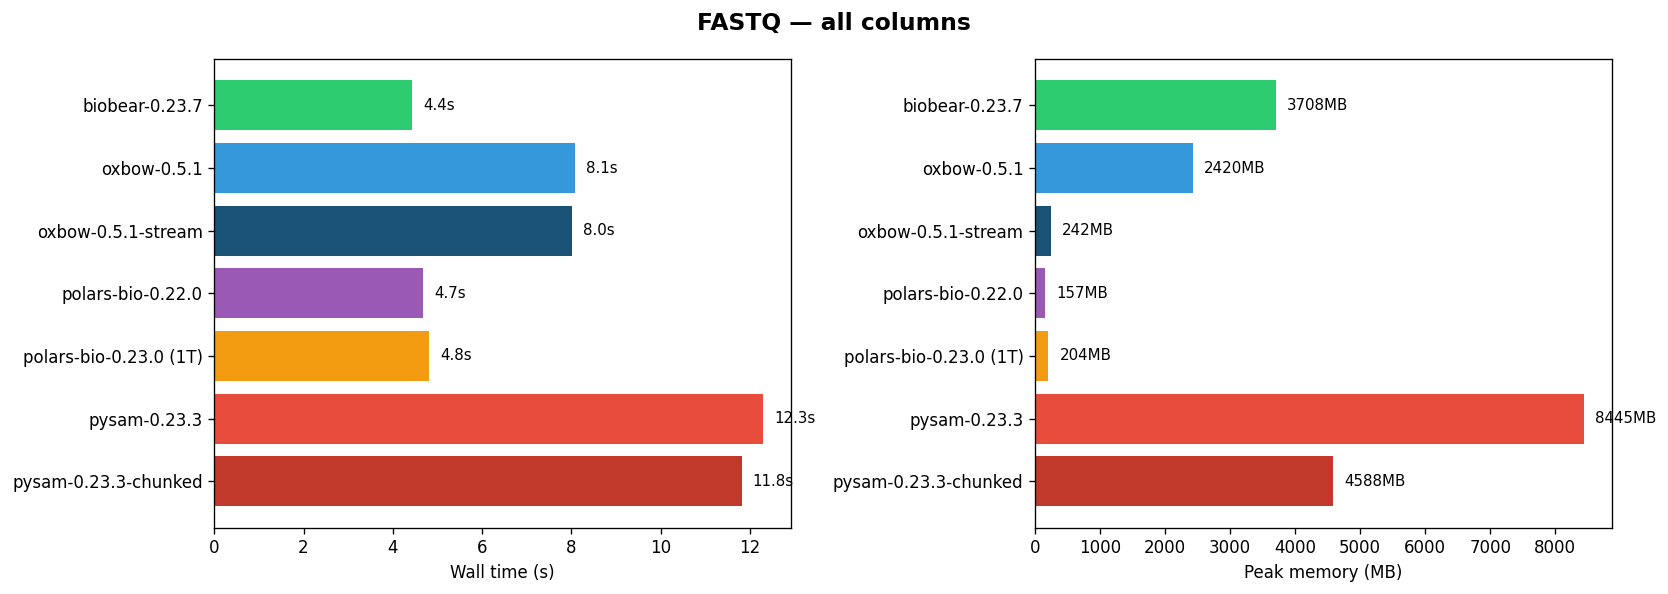

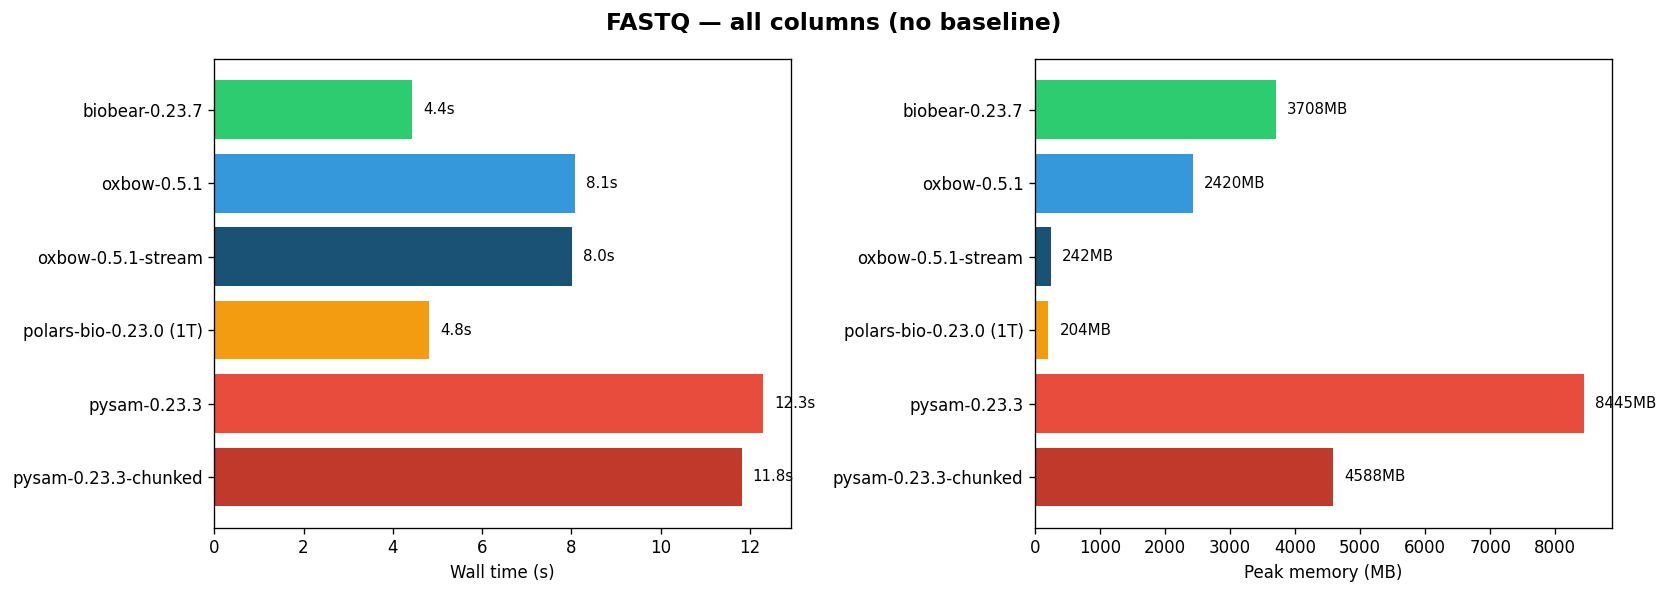

In [6]:
# Library comparison chart

def plot_library_comparison(df_median, fmt, variant, include_baseline=True):
    """Plot side-by-side wall time and peak memory for a format/variant.
    
    Args:
        include_baseline: If True, include polars-bio 0.22.0 baseline.
                         If False, exclude it from the chart.
    """
    title = FORMAT_TITLES[(fmt, variant)]
    if not include_baseline:
        title += " (no baseline)"
    
    # Filter: non-PB + PB baseline (optional) + PB prerelease at 1T only
    subset = df_median.filter(
        (pl.col("format") == fmt) & (pl.col("variant") == variant) &
        (
            ~pl.col("library").str.starts_with("polars_bio") |
            (pl.col("threads") == 1)
        )
    )
    
    if not include_baseline:
        subset = subset.filter(pl.col("library") != "polars_bio_baseline")
    
    subset = subset.sort("library")
    
    if len(subset) == 0:
        print(f"No data for {title}")
        return
    
    labels = subset["label"].to_list()
    times = subset["time_s"].to_list()
    mems = subset["peak_mb"].to_list()
    libs = subset["library"].to_list()
    colors = [COLORS.get(lib, "#95a5a6") for lib in libs]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight="bold")
    
    # Wall time
    bars1 = ax1.barh(labels, times, color=colors)
    ax1.set_xlabel("Wall time (s)")
    ax1.invert_yaxis()
    for bar, val in zip(bars1, times):
        ax1.text(bar.get_width() + max(times)*0.02, bar.get_y() + bar.get_height()/2,
                 f"{val:.1f}s", va="center", fontsize=9)
    
    # Peak memory
    bars2 = ax2.barh(labels, mems, color=colors)
    ax2.set_xlabel("Peak memory (MB)")
    ax2.invert_yaxis()
    for bar, val in zip(bars2, mems):
        ax2.text(bar.get_width() + max(mems)*0.02, bar.get_y() + bar.get_height()/2,
                 f"{val:.0f}MB", va="center", fontsize=9)
    
    plt.tight_layout()
    suffix = "" if include_baseline else "_no_baseline"
    fig.savefig(str(RESULTS_DIR / f"chart_{fmt}_{variant}{suffix}.png"), bbox_inches="tight")
    plt.show()

# FASTQ — all columns
plot_library_comparison(df_median, "fastq", "all_columns")
plot_library_comparison(df_median, "fastq", "all_columns", include_baseline=False)

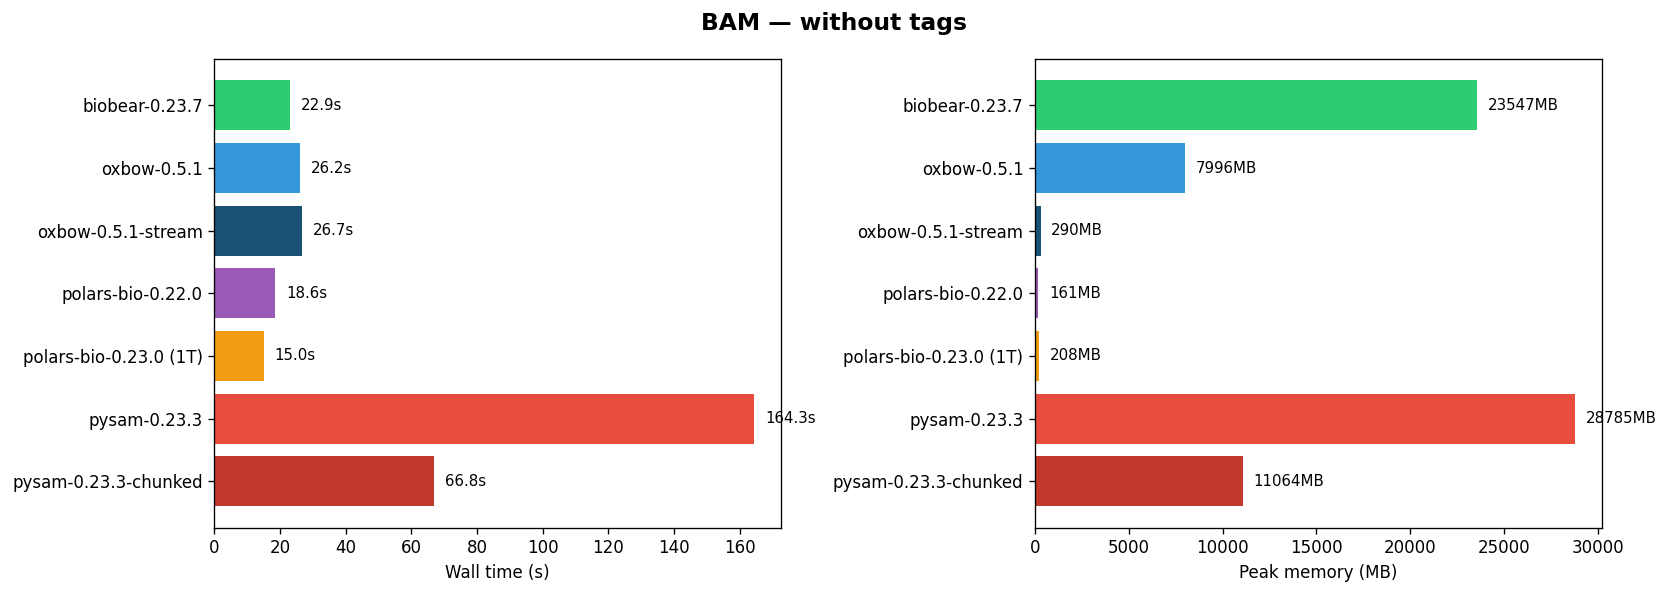

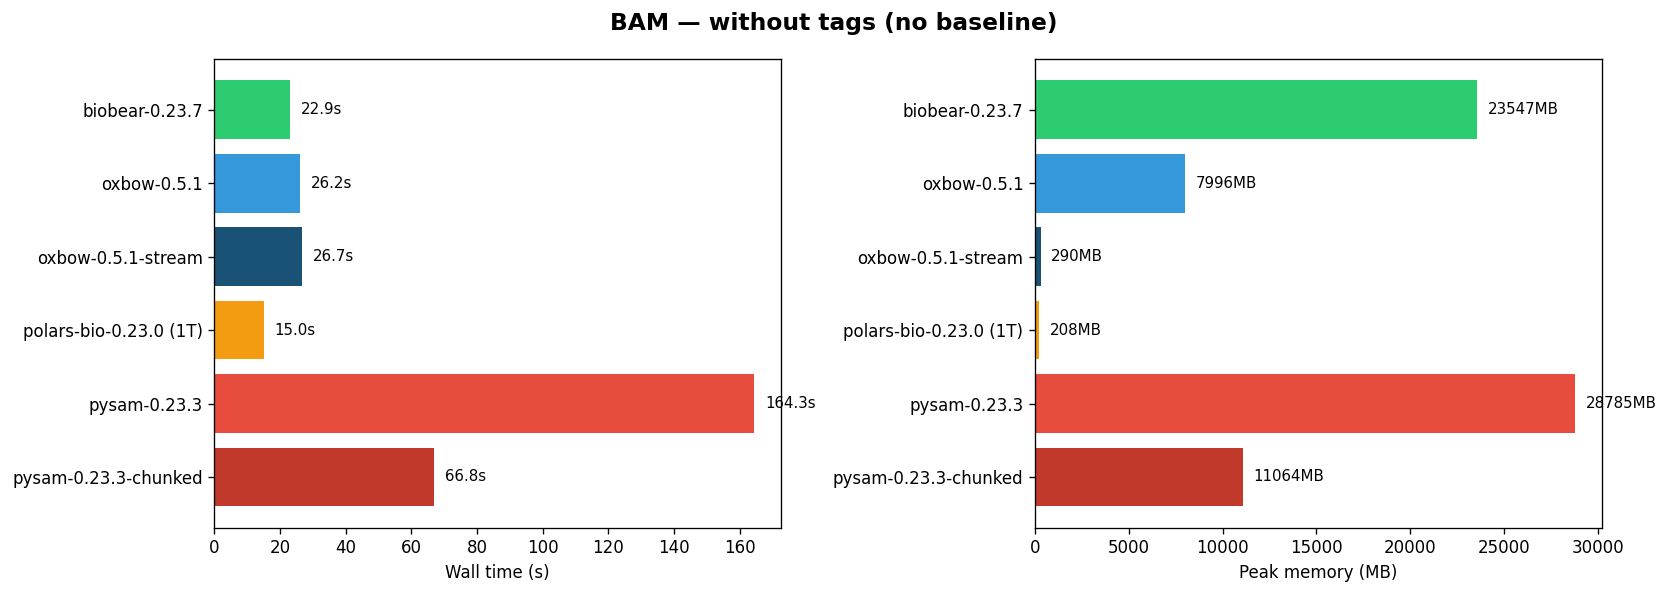

In [7]:
# BAM — without tags
plot_library_comparison(df_median, "bam", "without_tags")
plot_library_comparison(df_median, "bam", "without_tags", include_baseline=False)

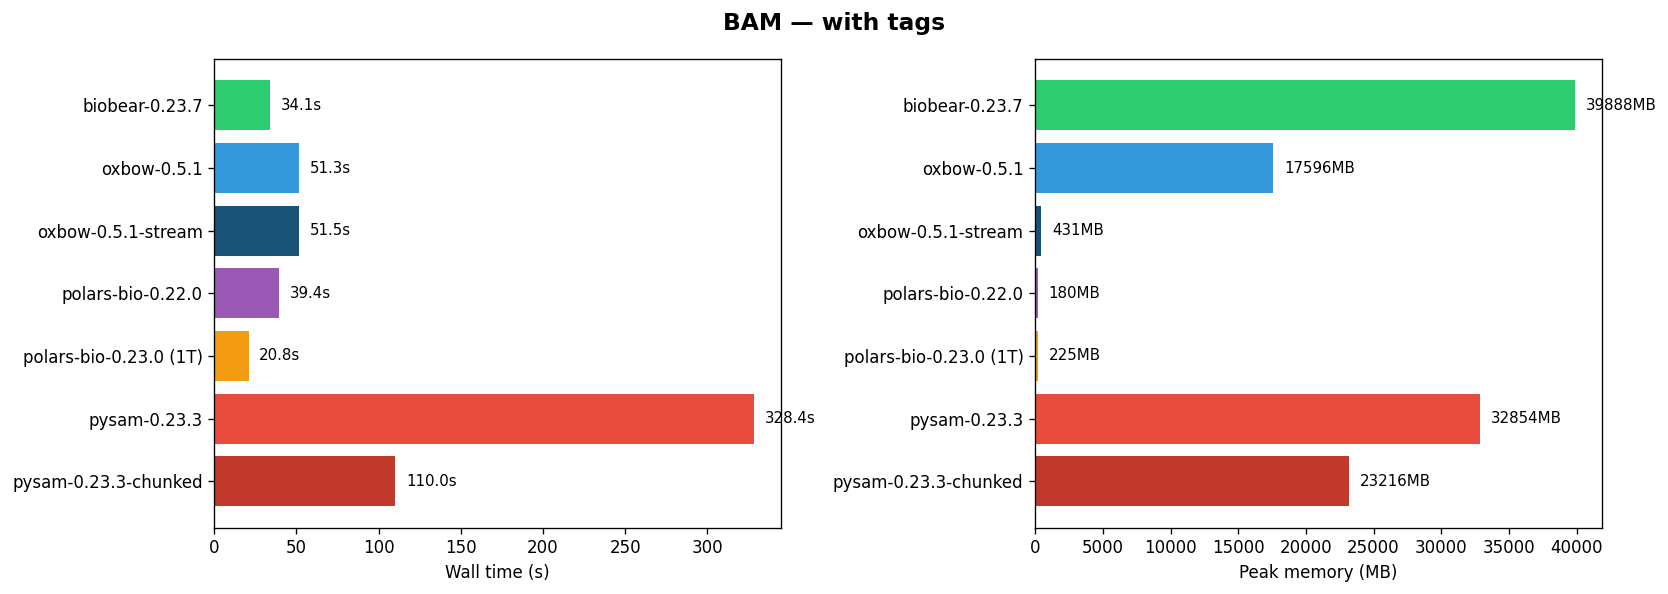

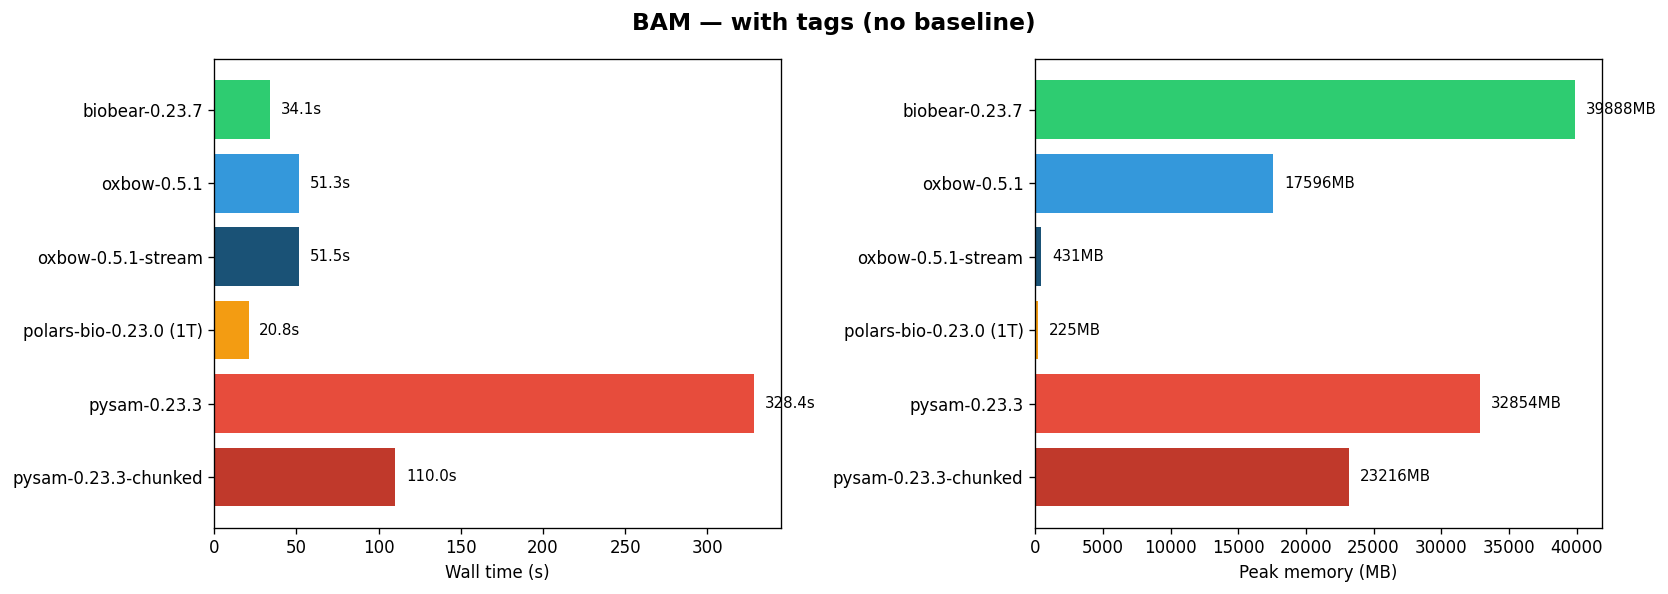

In [8]:
# BAM — with tags
plot_library_comparison(df_median, "bam", "with_tags")
plot_library_comparison(df_median, "bam", "with_tags", include_baseline=False)

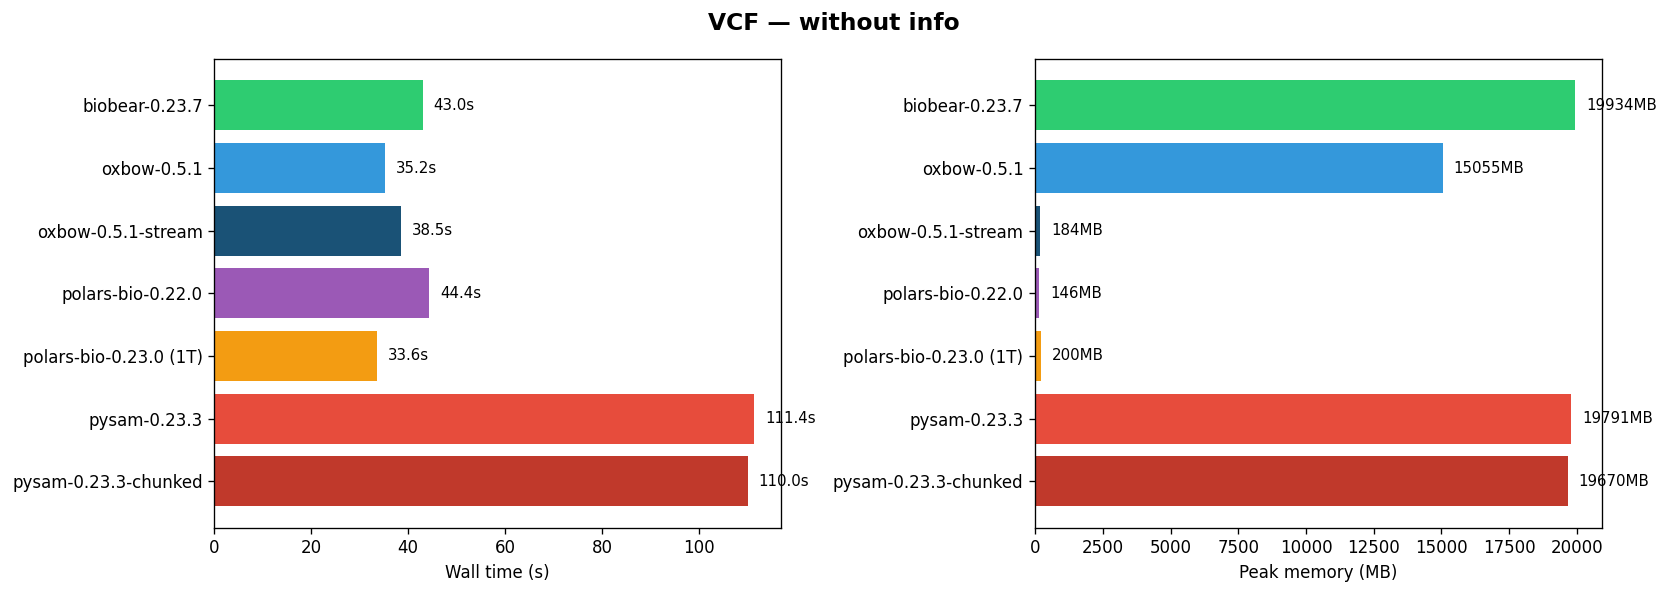

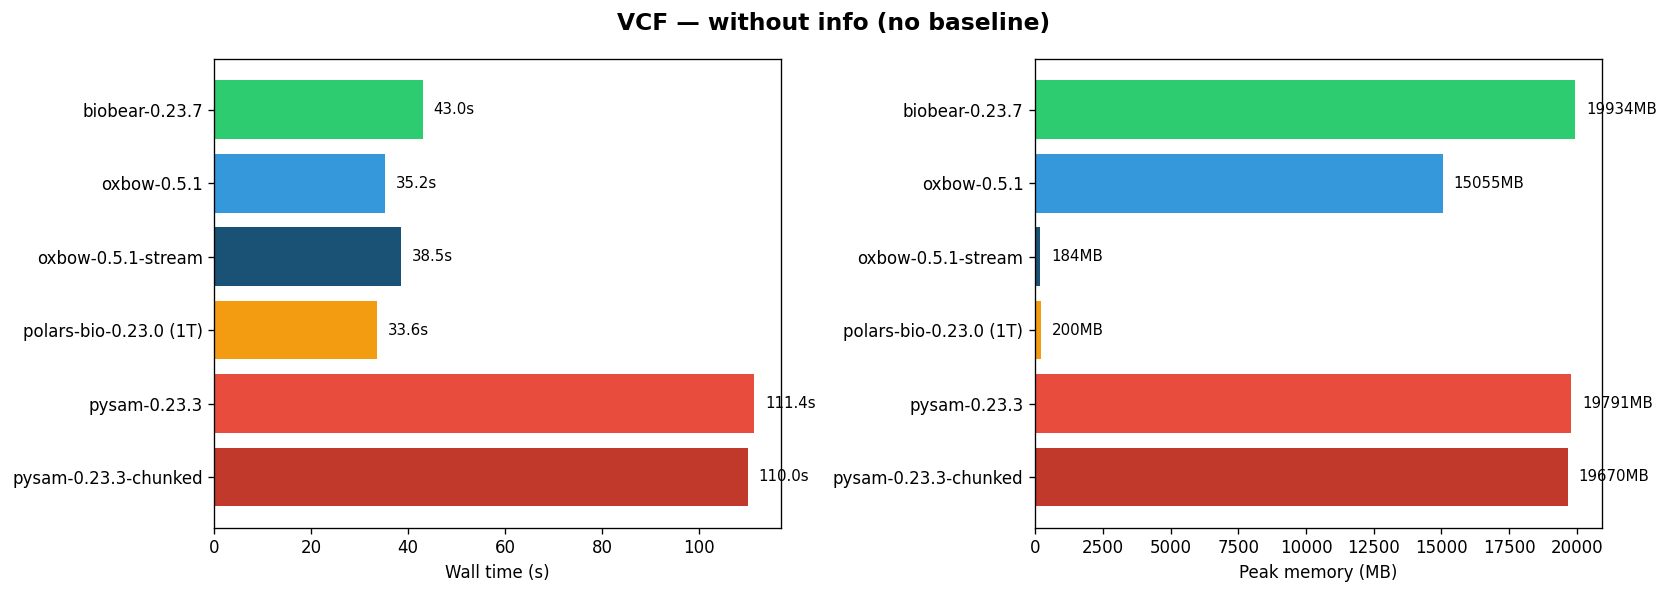

In [9]:
# VCF — without info
plot_library_comparison(df_median, "vcf", "without_info")
plot_library_comparison(df_median, "vcf", "without_info", include_baseline=False)

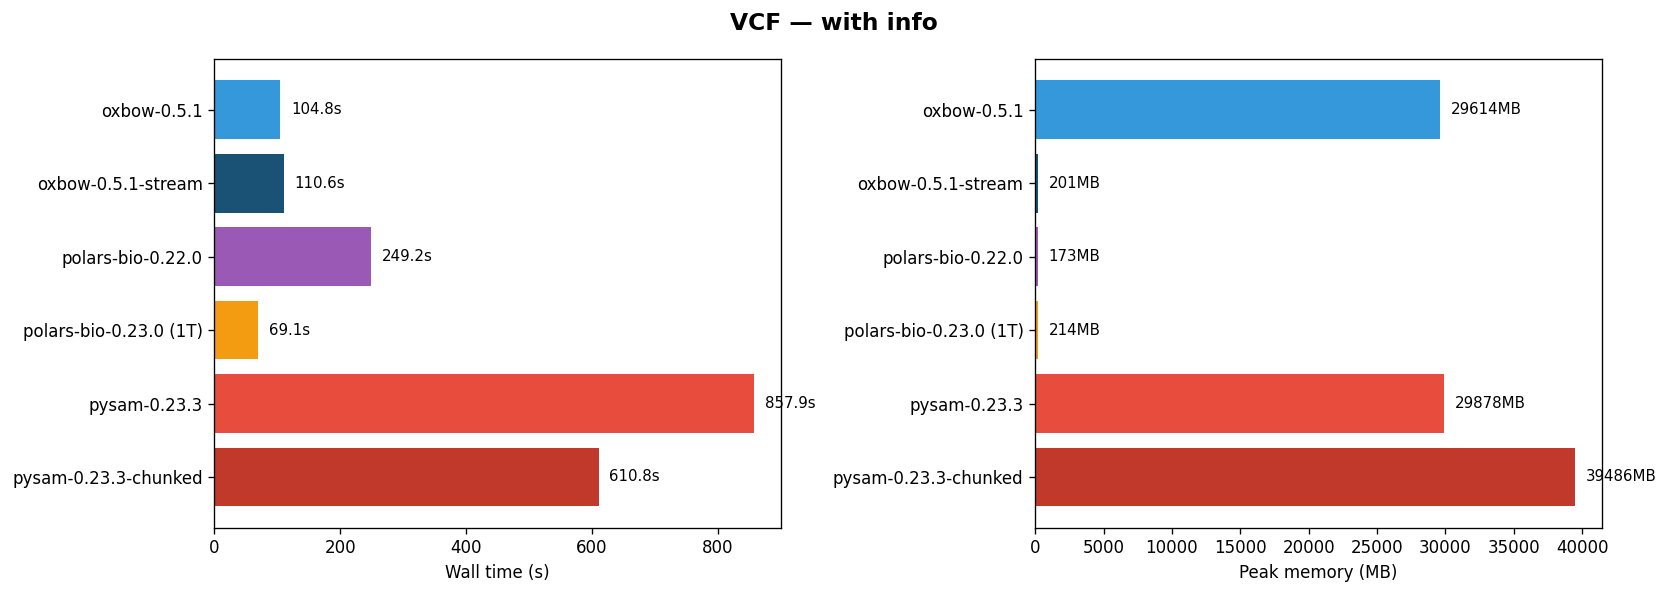

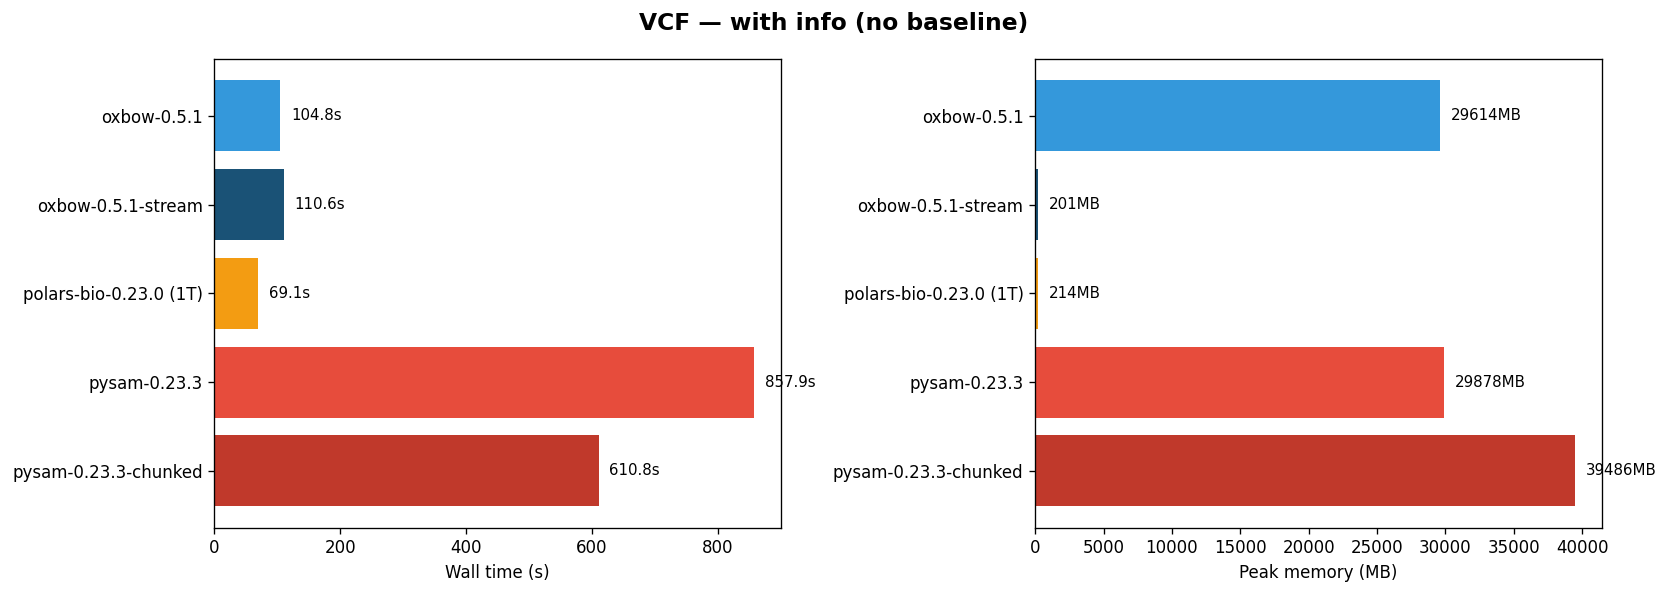

In [10]:
# VCF — with info
plot_library_comparison(df_median, "vcf", "with_info")
plot_library_comparison(df_median, "vcf", "with_info", include_baseline=False)

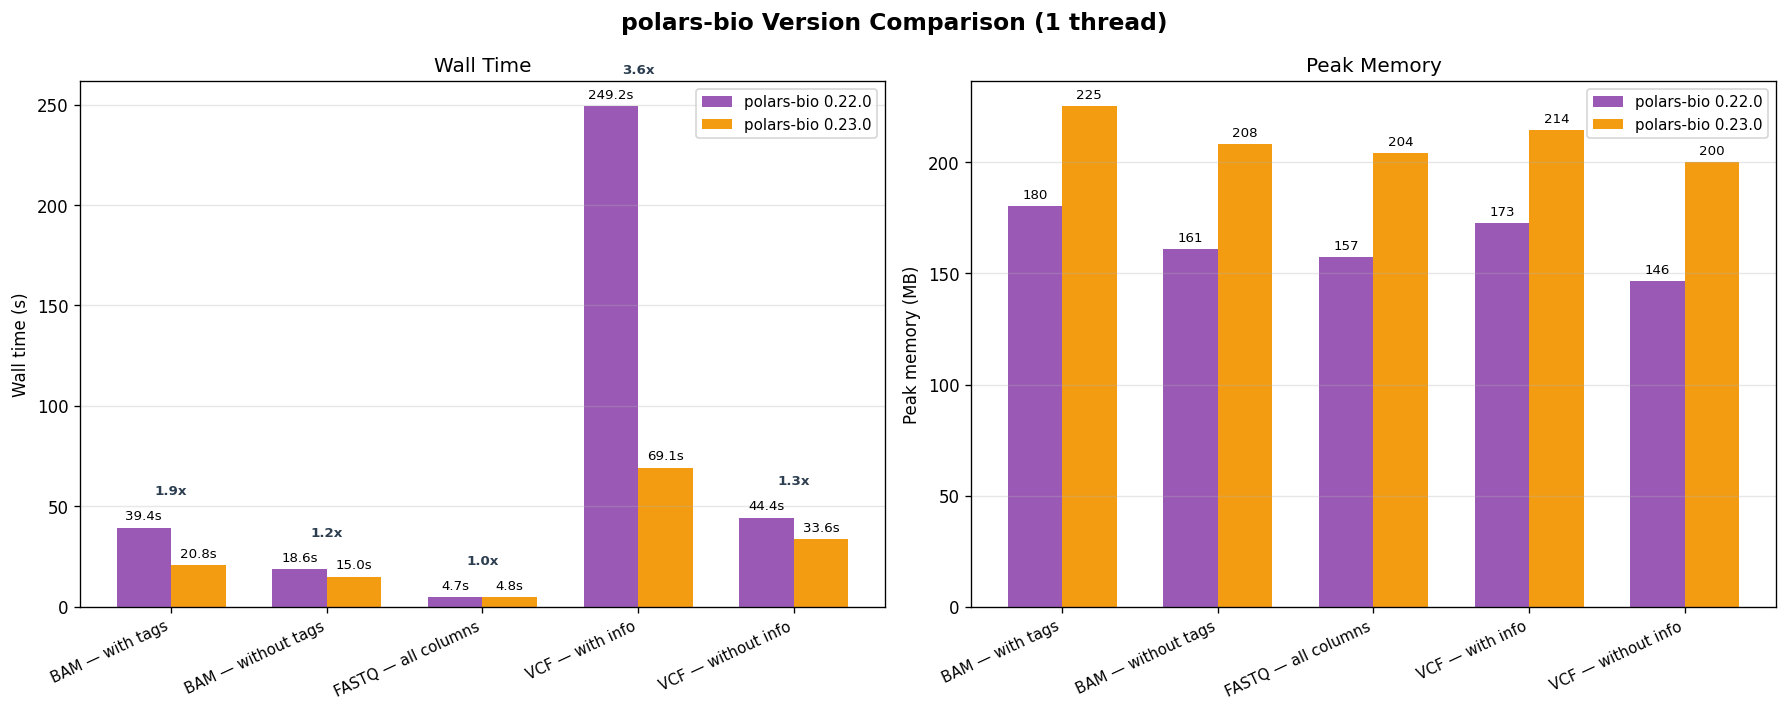

In [11]:
# polars-bio version comparison: 0.22.0 vs 0.23.0 (1T) across all tests

import numpy as np

def plot_polars_bio_comparison(df_median):
    pb_base = df_median.filter(
        (pl.col("library") == "polars_bio_baseline") & (pl.col("threads") == 1)
    ).sort("format", "variant")
    
    pb_pre = df_median.filter(
        (pl.col("library") == "polars_bio_prerelease") & (pl.col("threads") == 1)
    ).sort("format", "variant")
    
    # Build matched test labels
    test_labels = []
    base_times, pre_times = [], []
    base_mems, pre_mems = [], []
    
    for row in pb_base.iter_rows(named=True):
        key = (row["format"], row["variant"])
        label = FORMAT_TITLES.get(key, f"{row['format']}/{row['variant']}")
        match = pb_pre.filter(
            (pl.col("format") == row["format"]) & (pl.col("variant") == row["variant"])
        )
        if len(match) == 0:
            continue
        test_labels.append(label)
        base_times.append(row["time_s"])
        pre_times.append(match["time_s"][0])
        base_mems.append(row["peak_mb"])
        pre_mems.append(match["peak_mb"][0])
    
    n = len(test_labels)
    x = np.arange(n)
    w = 0.35
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle("polars-bio Version Comparison (1 thread)", fontsize=14, fontweight="bold")
    
    # Wall time
    b1 = ax1.bar(x - w/2, base_times, w, label="polars-bio 0.22.0", color=COLORS["polars_bio_baseline"])
    b2 = ax1.bar(x + w/2, pre_times, w, label="polars-bio 0.23.0", color=COLORS["polars_bio_prerelease"])
    ax1.set_ylabel("Wall time (s)")
    ax1.set_title("Wall Time")
    ax1.set_xticks(x)
    ax1.set_xticklabels(test_labels, rotation=25, ha="right", fontsize=9)
    ax1.legend(fontsize=9)
    ax1.grid(axis="y", alpha=0.3)
    
    for bars in [b1, b2]:
        for bar in bars:
            h = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2, h + max(base_times + pre_times)*0.01,
                     f"{h:.1f}s", ha="center", va="bottom", fontsize=8)
    
    # Speedup annotations
    for i in range(n):
        speedup = base_times[i] / pre_times[i]
        mid_x = x[i]
        top = max(base_times[i], pre_times[i])
        ax1.text(mid_x, top + max(base_times + pre_times)*0.06,
                 f"{speedup:.1f}x", ha="center", va="bottom", fontsize=8,
                 fontweight="bold", color="#2c3e50")
    
    # Peak memory
    b1 = ax2.bar(x - w/2, base_mems, w, label="polars-bio 0.22.0", color=COLORS["polars_bio_baseline"])
    b2 = ax2.bar(x + w/2, pre_mems, w, label="polars-bio 0.23.0", color=COLORS["polars_bio_prerelease"])
    ax2.set_ylabel("Peak memory (MB)")
    ax2.set_title("Peak Memory")
    ax2.set_xticks(x)
    ax2.set_xticklabels(test_labels, rotation=25, ha="right", fontsize=9)
    ax2.legend(fontsize=9)
    ax2.grid(axis="y", alpha=0.3)
    
    for bars in [b1, b2]:
        for bar in bars:
            h = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2, h + max(base_mems + pre_mems)*0.01,
                     f"{h:.0f}", ha="center", va="bottom", fontsize=8)
    
    plt.tight_layout()
    fig.savefig(str(RESULTS_DIR / "chart_polars_bio_comparison.png"), bbox_inches="tight")
    plt.show()

plot_polars_bio_comparison(df_median)

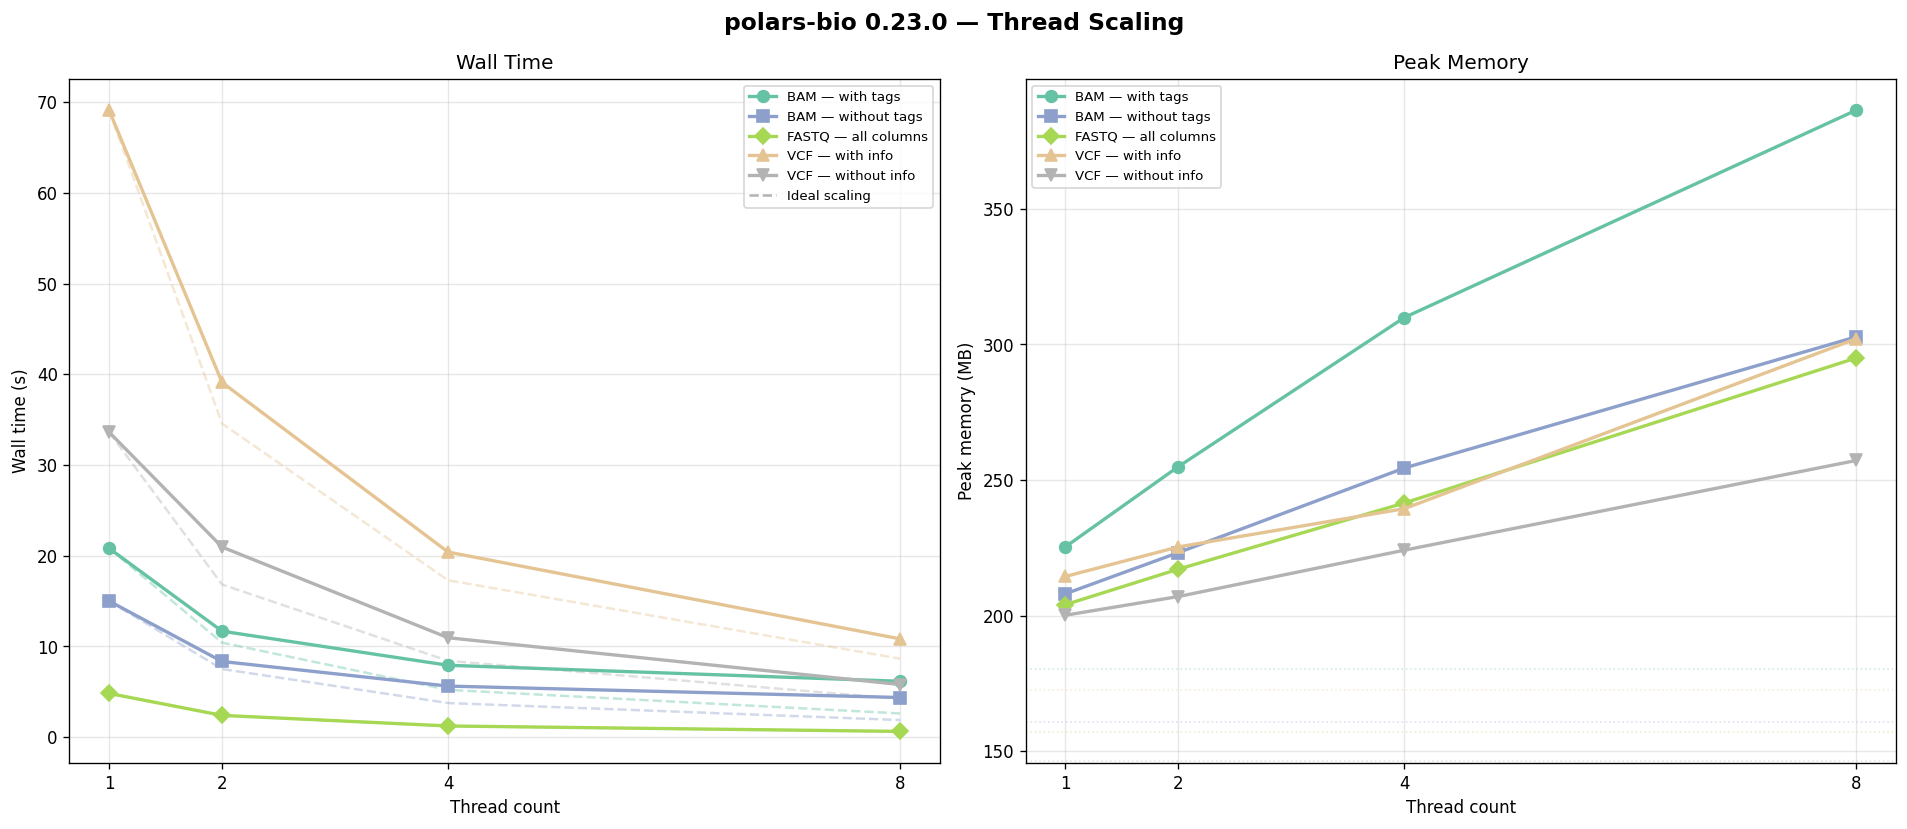

In [14]:
# Thread scaling — line charts with ideal scaling

def plot_thread_scaling():
    pb_pre = df_median.filter(pl.col("library") == "polars_bio_prerelease")
    pb_base = df_median.filter(
        (pl.col("library") == "polars_bio_baseline") & (pl.col("threads") == 1)
    )
    
    format_variants = pb_pre.select("format", "variant").unique().sort("format", "variant").rows()
    n = len(format_variants)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle("polars-bio 0.23.0 — Thread Scaling", fontsize=14, fontweight="bold")
    
    cmap = plt.cm.Set2
    markers = ["o", "s", "D", "^", "v"]
    
    # --- Wall time ---
    ax = axes[0]
    for i, (fmt, variant) in enumerate(format_variants):
        subset = pb_pre.filter(
            (pl.col("format") == fmt) & (pl.col("variant") == variant)
        ).sort("threads")
        threads = subset["threads"].to_list()
        times = subset["time_s"].to_list()
        label = FORMAT_TITLES.get((fmt, variant), f"{fmt}/{variant}")
        color = cmap(i / max(n - 1, 1))
        marker = markers[i % len(markers)]
        
        # Actual line
        ax.plot(threads, times, marker=marker, color=color, linewidth=2,
                markersize=7, label=label, zorder=3)
        
        # Ideal scaling dashed line (linear speedup from 1T time)
        if len(times) > 0:
            t1 = times[0]  # 1-thread baseline
            ideal = [t1 / t for t in threads]
            ax.plot(threads, ideal, linestyle="--", color=color, alpha=0.4,
                    linewidth=1.5, zorder=2)
    
    # Single "Ideal" entry for the legend
    ax.plot([], [], linestyle="--", color="gray", alpha=0.6, linewidth=1.5, label="Ideal scaling")
    
    ax.set_xlabel("Thread count")
    ax.set_ylabel("Wall time (s)")
    ax.set_title("Wall Time")
    ax.set_xticks(THREAD_COUNTS)
    ax.set_xticklabels([str(t) for t in THREAD_COUNTS])
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.3)
    
    # --- Peak memory ---
    ax = axes[1]
    for i, (fmt, variant) in enumerate(format_variants):
        subset = pb_pre.filter(
            (pl.col("format") == fmt) & (pl.col("variant") == variant)
        ).sort("threads")
        threads = subset["threads"].to_list()
        mems = subset["peak_mb"].to_list()
        label = FORMAT_TITLES.get((fmt, variant), f"{fmt}/{variant}")
        color = cmap(i / max(n - 1, 1))
        marker = markers[i % len(markers)]
        
        ax.plot(threads, mems, marker=marker, color=color, linewidth=2,
                markersize=7, label=label, zorder=3)
        
        # Baseline (0.22.0) dashed line
        base = pb_base.filter(
            (pl.col("format") == fmt) & (pl.col("variant") == variant)
        )
        if len(base) > 0:
            ax.axhline(y=base["peak_mb"][0], linestyle=":", color=color,
                       alpha=0.3, linewidth=1)
    
    ax.set_xlabel("Thread count")
    ax.set_ylabel("Peak memory (MB)")
    ax.set_title("Peak Memory")
    ax.set_xticks(THREAD_COUNTS)
    ax.set_xticklabels([str(t) for t in THREAD_COUNTS])
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    fig.savefig(str(RESULTS_DIR / "chart_thread_scaling.png"), bbox_inches="tight")
    plt.show()

plot_thread_scaling()

In [36]:
# Summary table

print("\n=== Benchmark Summary ===")
print(f"Total runs: {len(df)}")
print(f"Results saved to: {RESULTS_DIR / 'all_results.json'}")
print(f"Charts saved to: {RESULTS_DIR}/chart_*.png")
print()

# Show median table
with pl.Config(tbl_rows=100, tbl_cols=10, fmt_str_lengths=40):
    print(df_median.select("format", "variant", "label", "threads", "time_s", "peak_mb", "row_count"))


=== Benchmark Summary ===
Total runs: 88
Results saved to: /Users/mwiewior/research/git/bioformats-benchmark/results/all_results.json
Charts saved to: /Users/mwiewior/research/git/bioformats-benchmark/results/chart_*.png

shape: (44, 7)
┌────────┬──────────────┬────────────────────────┬─────────┬──────────┬─────────┬───────────┐
│ format ┆ variant      ┆ label                  ┆ threads ┆ time_s   ┆ peak_mb ┆ row_count │
│ ---    ┆ ---          ┆ ---                    ┆ ---     ┆ ---      ┆ ---     ┆ ---       │
│ str    ┆ str          ┆ str                    ┆ i64     ┆ f64      ┆ f64     ┆ i64       │
╞════════╪══════════════╪════════════════════════╪═════════╪══════════╪═════════╪═══════════╡
│ bam    ┆ with_tags    ┆ biobear-0.23.7         ┆ 1       ┆ 34.058   ┆ 39888.5 ┆ 19302411  │
│ bam    ┆ with_tags    ┆ oxbow-0.5.1            ┆ 1       ┆ 51.343   ┆ 17595.6 ┆ 19302411  │
│ bam    ┆ with_tags    ┆ oxbow-0.5.1-stream     ┆ 1       ┆ 51.513   ┆ 431.0   ┆ 19302411  │
│ bam    ┆